# Unveiling COVID-19: Data Exploration and Visualization




In [ ]:
!pip install pygal
!pip install wget
!pip install -U kaleido
!pip install stats

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).




---



# Import Packages

In [ ]:
# Import the necessary modules
import os
import wget
import pandas as pd
import numpy as np
import json

# Visualization libraries
import matplotlib.pyplot as plt
import pygal
from pygal import Config
from pygal.style import DefaultStyle
from scipy import stats
#seaborn: statistical visualization
import seaborn as sns
sns.set_style("whitegrid")




---



# Load Data

Data is already uploaded on Google Drive.

In [ ]:
# Read the Global Confirmed Cases Dataset
cases = pd.read_csv('time_series_covid19_confirmed_global.csv')
cases.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


In [ ]:
# Read the Death Dataset
deaths = pd.read_csv('time_series_covid19_deaths_global.csv')
deaths.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7896,7896,7896,7896,7896,7896,7896,7896,7896,7896
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3598,3598,3598,3598,3598,3598,3598,3598,3598,3598
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1933,1933,1933,1933,1933,1933,1933,1933,1933,1933




---



# Schema Analysis

In [ ]:
# Checking the data size
# confirmed cases
print("****GLOBAL CONFIRMED CASES*****")
print("# rows: {}".format(cases.shape[0]))
print("# columns: {}".format(cases.shape[1]))
print("****GLOBAL DEATHS*****")
print("# rows: {}".format(deaths.shape[0]))
print("# columns: {}".format(deaths.shape[1]))

****GLOBAL CONFIRMED CASES*****
# rows: 289
# columns: 1147
****GLOBAL DEATHS*****
# rows: 289
# columns: 1147


In [ ]:
# checking columns name
print("****All Columns Global Confirmed Cases****:\n", cases.columns)
print("\n")
print("****All Columns Gobal Deaths****:\n", deaths.columns)

****All Columns Global Confirmed Cases****:
 Index(['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20',
       '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       ...
       '2/28/23', '3/1/23', '3/2/23', '3/3/23', '3/4/23', '3/5/23', '3/6/23',
       '3/7/23', '3/8/23', '3/9/23'],
      dtype='object', length=1147)


****All Columns Gobal Deaths****:
 Index(['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20',
       '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       ...
       '2/28/23', '3/1/23', '3/2/23', '3/3/23', '3/4/23', '3/5/23', '3/6/23',
       '3/7/23', '3/8/23', '3/9/23'],
      dtype='object', length=1147)


In [ ]:
# checking data types
print("Global Confirmed Cases Types:\n", cases.dtypes)
print("\nGlobal Deaths Types:\n", deaths.dtypes)

Global Confirmed Cases Types:
 Province/State     object
Country/Region     object
Lat               float64
Long              float64
1/22/20             int64
                   ...   
3/5/23              int64
3/6/23              int64
3/7/23              int64
3/8/23              int64
3/9/23              int64
Length: 1147, dtype: object

Global Deaths Types:
 Province/State     object
Country/Region     object
Lat               float64
Long              float64
1/22/20             int64
                   ...   
3/5/23              int64
3/6/23              int64
3/7/23              int64
3/8/23              int64
3/9/23              int64
Length: 1147, dtype: object






---


# Data Consolidation

This section merges datasets on confirmed cases and deaths, extracting date information and creating separate data frames for each. These frames are then merged based on common identifiers, offering a comprehensive view of COVID-19 cases and fatalities over time.

In [ ]:
# Combine Confirmed & Death Cases

# Extract date data
date = cases.columns[4:]
# unpivot Global Confirmed Cases dataset
cases_df = cases.melt(id_vars=['Province/State','Country/Region','Lat','Long'],
                      value_vars = date, var_name = 'Date', value_name = 'Confirmed Cases')

# unpivot Gloal Deaths dataset
deaths_df = deaths.melt(id_vars=['Province/State', 'Country/Region','Lat','Long'],
                        value_vars = date, var_name = 'Date', value_name = 'Deaths')
# merged two new data frame
df = pd.concat([cases_df, deaths_df['Deaths']], axis = 1, sort = False)
# Check the data
df.tail()
#df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed Cases,Deaths
330322,NaN,West Bank and Gaza,31.952200,35.233200,3/9/23,703228,5708
330323,NaN,Winter Olympics 2022,39.904200,116.407400,3/9/23,535,0
330324,NaN,Yemen,15.552727,48.516388,3/9/23,11945,2159
330325,NaN,Zambia,-13.133897,27.849332,3/9/23,343135,4057
330326,NaN,Zimbabwe,-19.015438,29.154857,3/9/23,264276,5671


In [ ]:
# Save the data
df.to_csv('merged_uncleaned_data.csv')



---



# Data Cleaning

# Unique Values in the 'Province/State' Column.

In [ ]:
print("There are {} unique values for columns 'Province/State'".format(len(df['Province/State'].unique())))
df['Province/State'].unique()

There are 92 unique values for columns 'Province/State'


array([nan, 'Australian Capital Territory', 'New South Wales',
       'Northern Territory', 'Queensland', 'South Australia', 'Tasmania',
       'Victoria', 'Western Australia', 'Alberta', 'British Columbia',
       'Diamond Princess', 'Grand Princess', 'Manitoba', 'New Brunswick',
       'Newfoundland and Labrador', 'Northwest Territories',
       'Nova Scotia', 'Nunavut', 'Ontario', 'Prince Edward Island',
       'Quebec', 'Repatriated Travellers', 'Saskatchewan', 'Yukon',
       'Anhui', 'Beijing', 'Chongqing', 'Fujian', 'Gansu', 'Guangdong',
       'Guangxi', 'Guizhou', 'Hainan', 'Hebei', 'Heilongjiang', 'Henan',
       'Hong Kong', 'Hubei', 'Hunan', 'Inner Mongolia', 'Jiangsu',
       'Jiangxi', 'Jilin', 'Liaoning', 'Macau', 'Ningxia', 'Qinghai',
       'Shaanxi', 'Shandong', 'Shanghai', 'Shanxi', 'Sichuan', 'Tianjin',
       'Tibet', 'Unknown', 'Xinjiang', 'Yunnan', 'Zhejiang',
       'Faroe Islands', 'Greenland', 'French Guiana', 'French Polynesia',
       'Guadeloupe', 'Martiniq

In [ ]:
# Correct the values in 'Province/State'
# Remove the ',' in Bonaire, Sint Eustatius and Saba to avoid redundancy
df = df[df['Province/State'].str.contains(',')!=True]
# Check the number of column again
len(df['Province/State'].unique())

90

# Mapping Old Country Names to New Country Names

In [ ]:
country_dict = {'Taiwan*': 'Taiwan',
          'US': 'USA',
          'Korea, South':'South Korea',
          'Reunion':'Réunion',
          'Congo (Kinshasa)': 'Democratic Republic of the Congo',
          'Congo (Brazzaville)': 'Republic of the Congo',
          "Cote d'Ivoire": "Côte d'Ivoire",
           'Bahamas, The': 'Bahamas',
           'Gambia, The': 'Gambia'
    }

# Change the old country names with the new country names
for o,n in country_dict.items():
    df['Country/Region']=df['Country/Region'].replace(o,n)

<ipython-input-66-395f2b310ae4>:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
#print(df['Country/Region'].unique())
#print(len(df['Country/Region'].unique()))
# Checking the result
df[df['Country/Region']=='India'].head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed Cases,Deaths
148,NaN,India,20.593684,78.96288,1/22/20,0,0
437,NaN,India,20.593684,78.96288,1/23/20,0,0
726,NaN,India,20.593684,78.96288,1/24/20,0,0
1015,NaN,India,20.593684,78.96288,1/25/20,0,0
1304,NaN,India,20.593684,78.96288,1/26/20,0,0


In [ ]:
# Checking the data of India on 2/12/2020
df[(df['Country/Region']=='India')&(df['Date']=='8/18/20')]

,Province/State,Country/Region,Lat,Long,Date,Confirmed Cases,Deaths
60549,NaN,India,20.593684,78.96288,8/18/20,2767253,52888


# Convert Data From String to Datetime type.



In [ ]:
# Convert date from string to datetime type using pd.to_datetime
# Use strftime to sort the date order again (month, date, year)
df['Date']=pd.to_datetime(df['Date']).dt.strftime('%m/%d/%Y')
df.tail()

<ipython-input-69-ed17f2f6c162>:3: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



,Province/State,Country/Region,Lat,Long,Date,Confirmed Cases,Deaths
330322,NaN,West Bank and Gaza,31.952200,35.233200,03/09/2023,703228,5708
330323,NaN,Winter Olympics 2022,39.904200,116.407400,03/09/2023,535,0
330324,NaN,Yemen,15.552727,48.516388,03/09/2023,11945,2159
330325,NaN,Zambia,-13.133897,27.849332,03/09/2023,343135,4057
330326,NaN,Zimbabwe,-19.015438,29.154857,03/09/2023,264276,5671


Data is Cleaned.

In [ ]:
df.to_csv('covid19_clean_data.csv')

_______________ ____________
# Exploratory Data Analysis


In [ ]:
print("There are now {} variables and {} records in this dataset".format(df.shape[1],df.shape[0]))

There are now 7 variables and 328041 records in this dataset


### What are the lastest confirmed cases and deaths in the world?

In [ ]:
# Extract the final date of the dataframe
final_date = df.Date.iloc[-1]
# Extract the cases on the final_date
most_recent_df =df[df.Date == final_date]
# Most updated on Global COVID-19 confirmed cases and deaths
print("Globally COVID-19 information on {}:\n\
      \nConfirmed Cases: {:,}\nDeaths: {:,}".format(final_date,
                             most_recent_df["Confirmed Cases"].sum(),   # Lastest info about confirmed cases
                             most_recent_df["Deaths"].sum()))           # Lastest info about deaths


Globally COVID-19 information on 03/09/2023:
      
Confirmed Cases: 676,556,179
Deaths: 6,881,761


### An overview of COVID-19 fatality and recovery rate at Global level

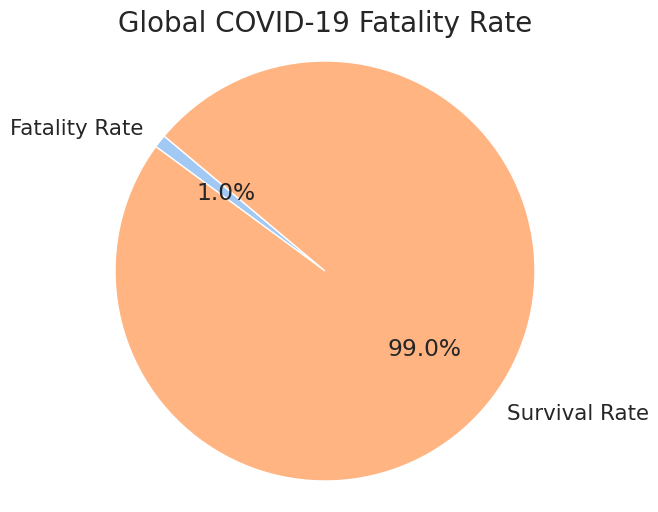

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate global fatality rate
fatality_rate = round((most_recent_df["Deaths"].sum()/ most_recent_df["Confirmed Cases"].sum())*100,2)

# Define data
labels = ['Fatality Rate', 'Survival Rate']
sizes = [fatality_rate, 100 - fatality_rate]  # Fatality rate and the complementary survival rate

# Set seaborn style
sns.set_style("whitegrid")

# Choose color palette
colors = sns.color_palette("pastel")

# Create pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')

# Add title
plt.title('Global COVID-19 Fatality Rate')

# Show plot
plt.show()


### Displaying Fatality Rate and Highlighting Countries by Cases and Deaths

In [ ]:
# Define the fatality_rate function
def fatality_rate(deaths, confirmed_cases):
    return (deaths / confirmed_cases) * 100 if confirmed_cases > 0 else 0

# Extract the data by country on the most recent date
country_data = most_recent_df.groupby('Country/Region')[['Confirmed Cases', 'Deaths']]\
                              .sum()\
                              .reset_index()

# Calculate fatality rate
country_data['fatality_rate'] = country_data.apply(lambda row: fatality_rate(row['Deaths'], row['Confirmed Cases']), axis=1)

# Color palette for cmap is diverging orange red
color_cases = 'OrRd'
color_death = 'OrRd'
color_f = 'OrRd'

# Create a highlighting color on country cases table
cmap_country = country_data.sort_values('Confirmed Cases', ascending=False)\
                           .reset_index(drop=True)\
                           .style.background_gradient(cmap=color_cases, subset=['Confirmed Cases'])\
                           .background_gradient(cmap=color_death, subset=['Deaths'])\
                           .background_gradient(cmap=color_f, subset=['fatality_rate'])

display(cmap_country)


,Country/Region,Confirmed Cases,Deaths,fatality_rate
0,USA,103802702,1123836,1.082665
1,India,44690738,530779,1.187671
2,France,39866718,166176,0.416829
3,Germany,38249060,168935,0.441671
4,Brazil,37076053,699276,1.886058
5,Japan,33320438,72997,0.219076
6,South Korea,30615522,34093,0.111359
7,Italy,25603510,188322,0.735532
8,United Kingdom,24656539,220721,0.895182
9,Russia,22075858,388478,1.759741




--- ---



# EXPLORE THE SPREAD OF COVID-19 IN TOP 10 COUNTRY


1. What are top 10 most-affected countries with the highest number of COVID-19 cases?
2. What are top 10 deathly countries with the highest number of COVID-19 fatalities?
3. Which worst affected countries had the highest fatality rate?
4. Which most deathly countries had the highest fatality rate ?

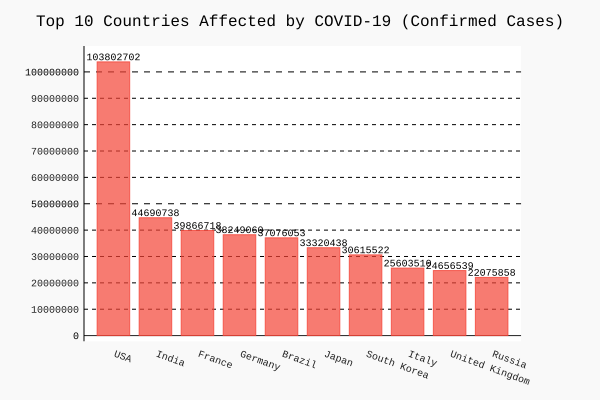

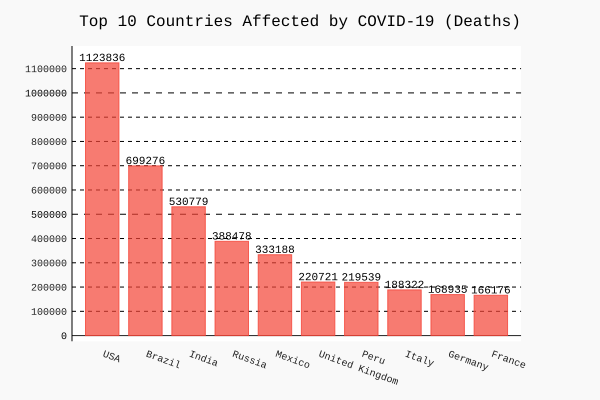

In [ ]:
import pygal
from pygal.style import DefaultStyle
from IPython.display import SVG

# Extract the top 10 countries with the highest number of confirmed cases
top10_countries_confirmed = country_data.sort_values('Confirmed Cases', ascending=False).head(10)

# Plot a bar chart for the top 10 countries by confirmed cases
chart_confirmed = pygal.Bar(
    show_legend=False,
    human_readable=True,
    fill=True,
    width=600,
    height=400,
    x_label_rotation=20,
    print_values=True,
    print_values_position='top',
    style=DefaultStyle(value_font_size=10, value_colors=('black',))
)
chart_confirmed.title = 'Top 10 Countries Affected by COVID-19 (Confirmed Cases)'
chart_confirmed.x_labels = top10_countries_confirmed['Country/Region']
chart_confirmed.add('Confirmed Cases', top10_countries_confirmed['Confirmed Cases'])

# Display the bar chart for confirmed cases
display(SVG(chart_confirmed.render(disable_xml_declaration=True)))

# Extract the top 10 countries with the highest number of deaths
top10_countries_deaths = country_data.sort_values('Deaths', ascending=False).head(10)

# Plot a bar chart for the top 10 countries by deaths
chart_deaths = pygal.Bar(
    show_legend=False,
    human_readable=True,
    fill=True,
    width=600,
    height=400,
    x_label_rotation=20,
    print_values=True,
    print_values_position='top',
    style=DefaultStyle(value_font_size=11, value_colors=('black',))
)
chart_deaths.title = 'Top 10 Countries Affected by COVID-19 (Deaths)'
chart_deaths.x_labels = top10_countries_deaths['Country/Region']
chart_deaths.add('Deaths', top10_countries_deaths['Deaths'])

# Display the bar chart for deaths
display(SVG(chart_deaths.render(disable_xml_declaration=True)))


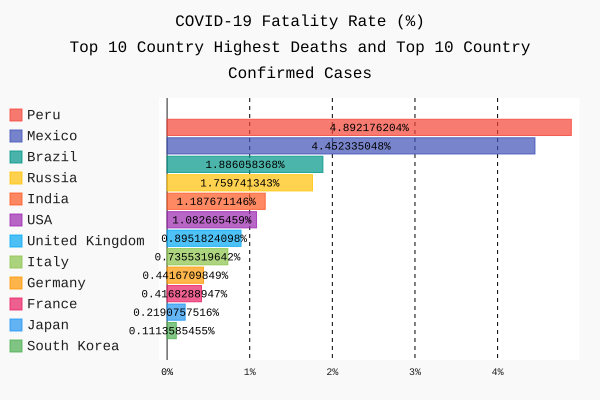

In [ ]:
#### DATA PREP ###
# Calculate fatality rate for top 10 country with highest confirmed cases
top10_countries_confirmed['fatality_rate'] = top10_countries_confirmed[['Confirmed Cases','Deaths']]\
        .apply(lambda row: fatality_rate(row["Deaths"], row["Confirmed Cases"]), axis=1)

# Calculate fatality rate for top 10 country with highest deaths
top10_countries_deaths['fatality_rate'] = top10_countries_deaths[['Confirmed Cases','Deaths']]\
        .apply(lambda row: fatality_rate(row["Deaths"], row["Confirmed Cases"]), axis=1)

# Combine data of country with highest confirmed cases and highest deaths
df_country_top10 = pd.concat([top10_countries_deaths,top10_countries_confirmed]).drop_duplicates().sort_values('fatality_rate',
                                                                                                ascending=False)
##### PLOT HORIZONTAL BAR CHART TO DISPLAY FATALITY RATE ####
# Plot COVID-19 Fatality Rate for Top 10 Country with Highest Confirmed Cases and Highest Deths
chart_f = pygal.HorizontalBar(print_values=True, width = 600,
    height = 400,                              # Set chart configuration
                              style = DefaultStyle(value_font_size = 11, value_colors=('black',)))
percent_formatter = lambda x: '{:.10g}%'.format(x)                             # format fatality rate in %
chart_f.value_formatter = percent_formatter
chart_f.title = "COVID-19 Fatality Rate (%)\n Top 10 Country Highest Deaths and Top 10 Country Confirmed Cases"                   # Set chart title
for country,rate in zip(df_country_top10["Country/Region"],              # Add value to chart
                        df_country_top10["fatality_rate"]):
    chart_f.add(country,rate)
display(SVG(chart_f.render(disable_xml_declaration=True)))

# TOP 10 Fatality Rate Countries In The World

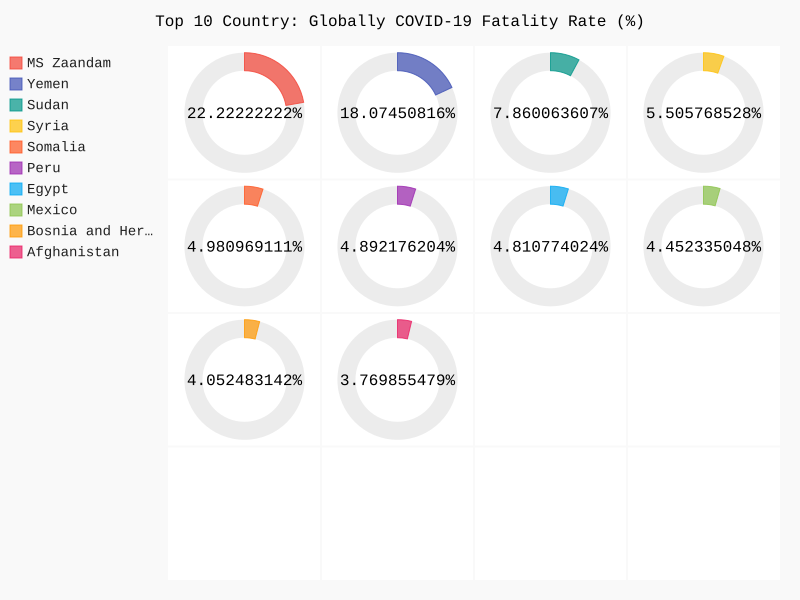

In [ ]:
### Top 10 COVID-19 Fatality Rate (Globally)
top10_country_fatality = country_data.sort_values('fatality_rate', ascending=False).iloc[1:11]
### Top 10 COVID-19 Fatality Rate (Globally)
top10_country_fatality = country_data.sort_values('fatality_rate', ascending=False).iloc[1:11]

# Plot Fatality Rate for top highest country/region globally
gauge_fatality = pygal.SolidGauge(inner_radius=0.70)
percent_formatter = lambda x: '{:.10g}%'.format(x)
gauge_fatality.value_formatter = percent_formatter
gauge_fatality.title = "Top 10 Country: Globally COVID-19 Fatality Rate (%)"            # Set title
for country, rate in zip(top10_country_fatality["Country/Region"], top10_country_fatality["fatality_rate"]):
    gauge_fatality.add(country, [{'value': rate}])
display(SVG(gauge_fatality.render(disable_xml_declaration=True))) # Show chart


### Summarizing World COVID-19 Cases Over Time

In [ ]:
# Data preparation
# Sum up all the cases in the world by date
world_cases_all_time = df.groupby('Date')[['Confirmed Cases','Deaths']].sum().sort_values('Date', ascending=False).reset_index()
# Add new confirmed cases which indicates the difference between day of confirmed cases
# For example - 99 is the number of cases increased from 555 in 2020-1-22 to 654 in 2020-1-23
world_cases_all_time['New Cases'] = world_cases_all_time['Confirmed Cases'] - world_cases_all_time['Confirmed Cases'].shift(1)
# For good x-axis display, show only month & year
world_cases_all_time['Date'] = pd.to_datetime(world_cases_all_time['Date'])
# Sort data by date since day 1 till current time
world_cases_all_time = world_cases_all_time.sort_values("Date").reset_index(drop=True)
# Check data again
world_cases_all_time.tail()


,Date,Confirmed Cases,Deaths,New Cases
1138,2023-03-05,676010931,6877708,675908869.0
1139,2023-03-06,676068971,6878074,675962772.0
1140,2023-03-07,676199408,6878997,676089411.0
1141,2023-03-08,676378854,6880442,676264562.0
1142,2023-03-09,676556179,6881761,676437128.0


### Global Daily Changes in Confirmed Cases and Deaths Over Time (01/2020 to 01/2021)

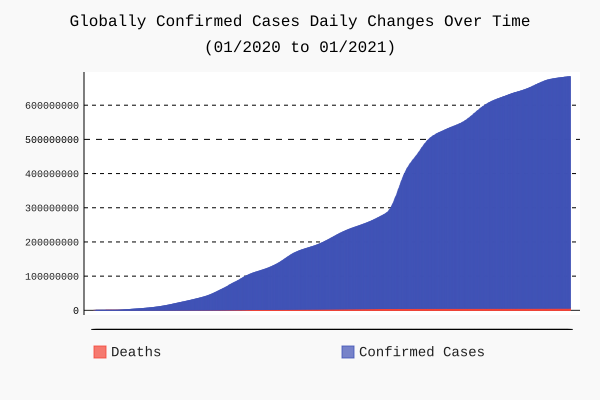

In [ ]:
# STACKED BAR CHART
line_chart_cf = pygal.StackedBar(height=400, width=600, legend_at_bottom = True, interpolate='cubic')
line_chart_cf.title = 'Globally Confirmed Cases Daily Changes Over Time\n(01/2020 to 01/2021)'
line_chart_cf.x_labels = [str(i) for i in world_cases_all_time['Date']]
line_chart_cf.add('Deaths', [i for i in world_cases_all_time['Deaths']])
line_chart_cf.add('Confirmed Cases', [i for i in world_cases_all_time['Confirmed Cases']])
display(SVG(line_chart_cf.render(disable_xml_declaration=True)))

# Country Comparison Since The Early Stage Of The Pandemic

In [ ]:
# Sum up all cases for each country by date
countries_cases_all_time = df.groupby(['Date','Country/Region'])[['Confirmed Cases','Deaths']]\
    .sum().sort_values('Date').reset_index()

# Find top 10 countries with the highest number of confirmed cases
top10_country = country_data.sort_values('Confirmed Cases', ascending=False)\
            .head(10)['Country/Region'].unique()

print("Top 10 countries with highest confirmed cases are: \n\n{}".format(set(top10_country)))

# Extract top 10 countries cases from countries cases all time
top10_country_cases = countries_cases_all_time[countries_cases_all_time['Country/Region'].isin(top10_country)]

# Convert the date to datetime format
top10_country_cases['Date'] = pd.to_datetime(top10_country_cases['Date'])

# Calculate Log of Confirmed Cases & Deaths
top10_country_cases['Log(Confirmed Cases)'] = np.log(top10_country_cases['Confirmed Cases'])
top10_country_cases['Log(Deaths)'] = np.log(top10_country_cases['Deaths'])

top10_country_cases.head()


Top 10 countries with highest confirmed cases are: 

{'Russia', 'USA', 'Germany', 'Brazil', 'United Kingdom', 'South Korea', 'Italy', 'Japan', 'India', 'France'}


<ipython-input-80-05ddbf6f3c2f>:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning:

divide by zero encountered in log

<ipython-input-80-05ddbf6f3c2f>:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning:

divide by zero encountered in log

<ipython-input-80-05ddbf6f3c2f>:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a

,Date,Country/Region,Confirmed Cases,Deaths,Log(Confirmed Cases),Log(Deaths)
19,2021-01-01,Russia,3153960,56798,14.964169,10.947256
57,2021-01-01,USA,20397398,352844,16.830918,12.773781
61,2021-01-01,United Kingdom,2549667,95917,14.751473,11.471239
98,2021-01-01,South Korea,62593,942,11.044409,6.848005
125,2021-01-01,Brazil,7703971,195541,15.857246,12.183525


### Top 10 Wost Affected Countries Since The Early Stage of The Pandemic

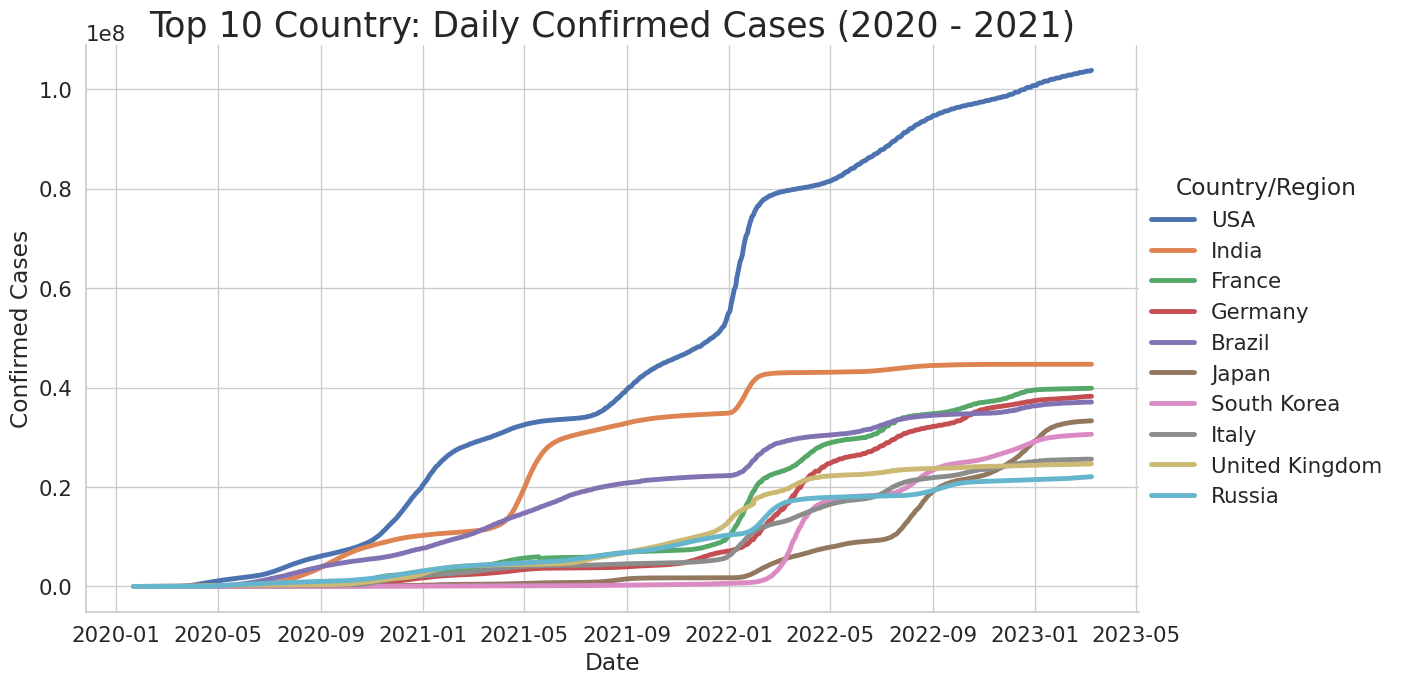

In [ ]:
sns.set(style="whitegrid")
sns.set_context("notebook", font_scale=1.4, rc={"lines.linewidth":3.5,"axes.titlesize":25})
# Plot the confirmed cases comparison between countries
sns.relplot( data = top10_country_cases, x="Date", y="Confirmed Cases", hue="Country/Region", hue_order = top10_country,
    kind="line", height=7, aspect=1.7, facet_kws=dict(sharex=False))\
.set(title="Top 10 Country: Daily Confirmed Cases (2020 - 2021)")
plt.show()

### Have top 10 affected countries flattened the death curves ?

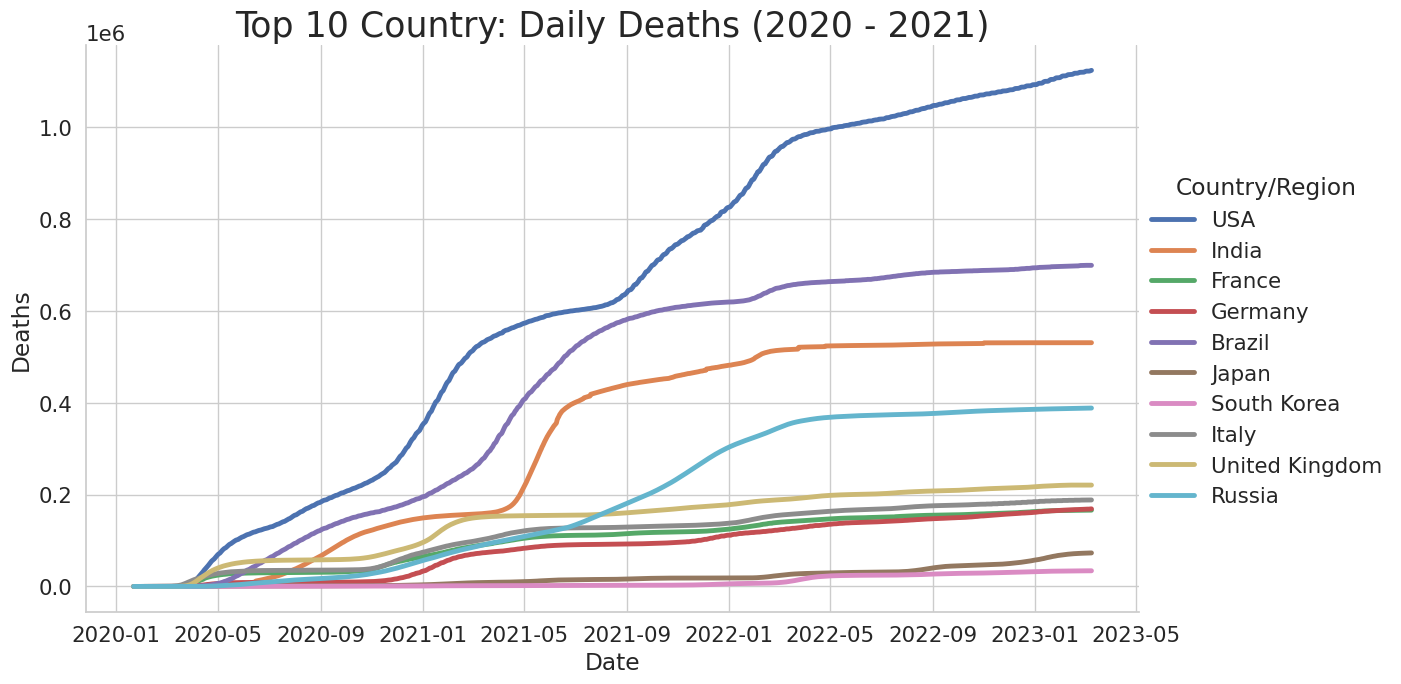

In [ ]:
sns.set(style="whitegrid")
sns.set_context("notebook", font_scale=1.4, rc={"lines.linewidth":3.5,
                                               "axes.titlesize":25})
# Plot the deaths comparison between countries
sns.relplot(
    data = top10_country_cases, x="Date", y="Deaths",
    hue="Country/Region",
    hue_order = top10_country,
    kind="line",
    height=7, aspect=1.7, facet_kws=dict(sharex=False))\
.set(title="Top 10 Country: Daily Deaths (2020 - 2021)")
plt.show();

### Targeted Country Comparison Since The Early Stage of The Pandemic

In [ ]:
# Set the targeted countries list
targeted_countries=['USA','China','Mexico', 'Vietnam','South Korea',
                             'Brazil','Spain','Russia','India',
                             'United Kingdom']
targeted_countries_cases = countries_cases_all_time[countries_cases_all_time['Country/Region'].isin(targeted_countries)]
targeted_countries_cases['Date'] = pd.to_datetime(targeted_countries_cases['Date'])

<ipython-input-83-2f9c0f53d24e>:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



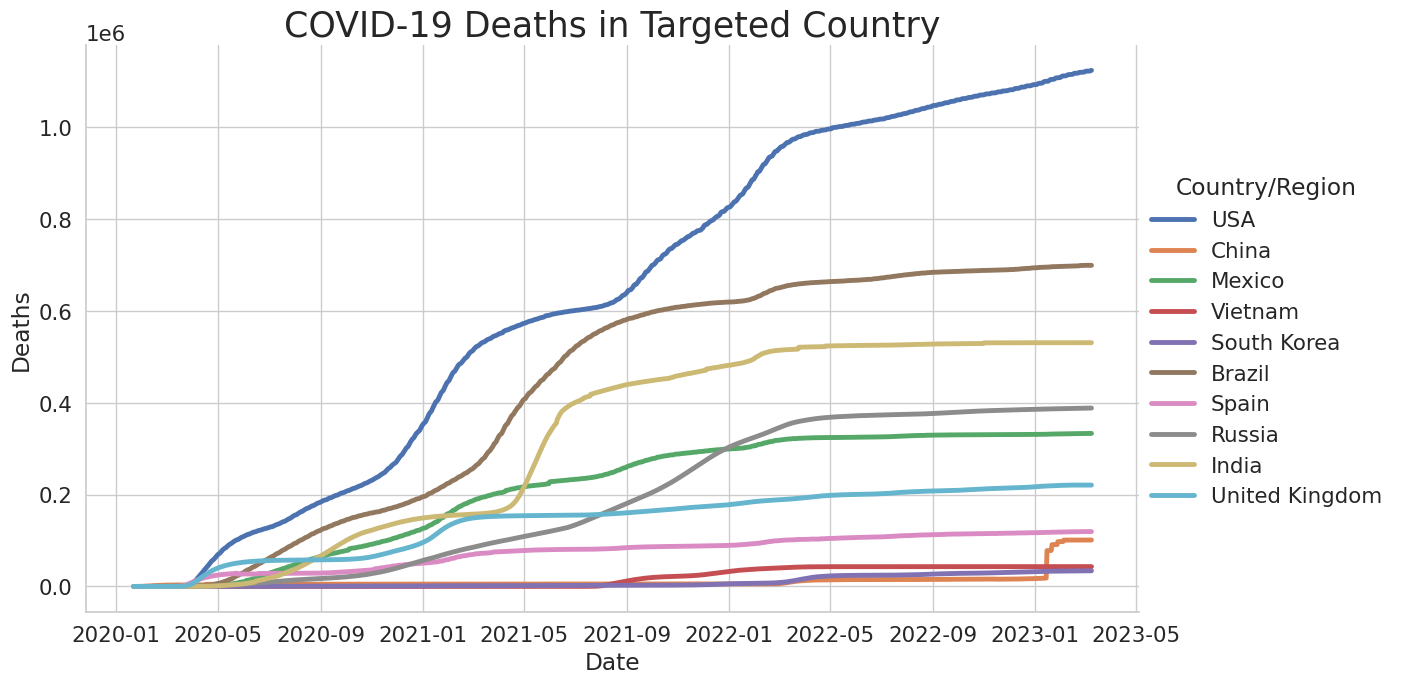

In [ ]:
sns.set(style="whitegrid")
sns.set_context("notebook", font_scale=1.4, rc={"lines.linewidth":3.5,
                                               "axes.titlesize":25})
sns.relplot(
    data = targeted_countries_cases, x="Date", y="Deaths",
    hue="Country/Region",
    hue_order = targeted_countries,
    kind="line",
    height=7, aspect=1.7, facet_kws=dict(sharex=False))\
.set(title="COVID-19 Deaths in Targeted Country")
plt.show();

### Kernel Density Estimation (KDE) Plots for Top 10 Countries

<ipython-input-85-27c4e88c46d6>:14: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


<ipython-input-85-27c4e88c46d6>:18: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




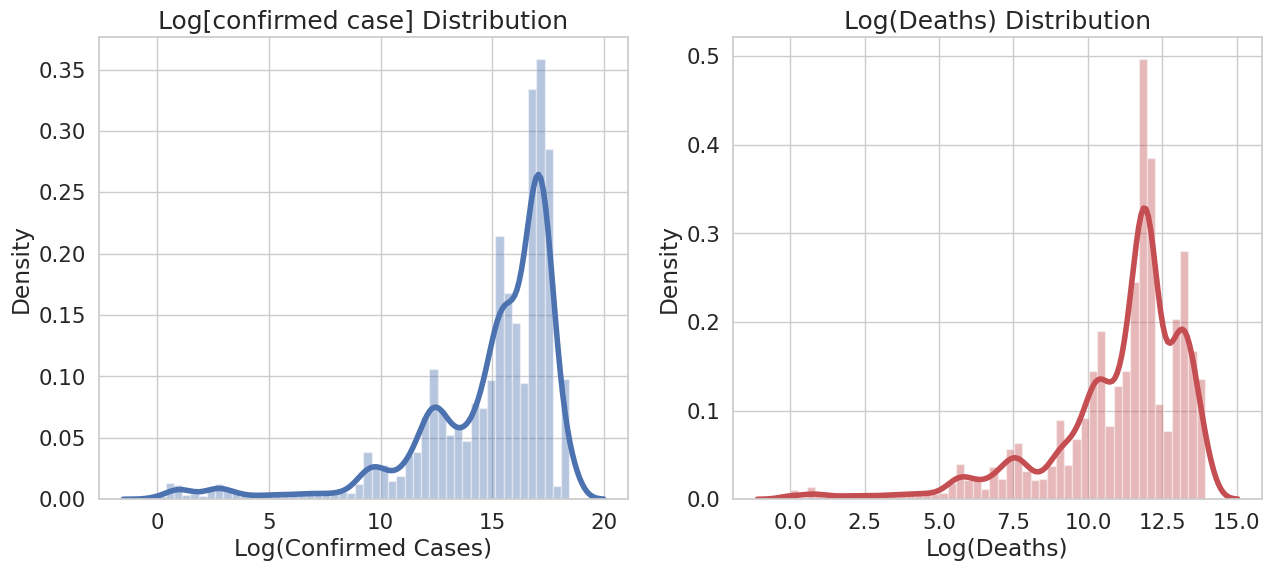

In [ ]:
sns.set(style="whitegrid")
sns.set_context("notebook", font_scale=1.4, rc={"lines.linewidth": 4, "axes.titlesize": 18})

# Filter out non-finite values from the data
filtered_cases = top10_country_cases[np.isfinite(top10_country_cases['Log(Confirmed Cases)'])]
filtered_deaths = top10_country_cases[np.isfinite(top10_country_cases['Log(Deaths)'])]

# Define the number of bins for the KDE plot
num_bins = 50

f, ax = plt.subplots(figsize=(15, 6), ncols=2)

# Plot KDE US new cases
sns.distplot(filtered_cases['Log(Confirmed Cases)'].iloc[1:], kde=True, ax=ax[0], bins=num_bins)
ax[0].set_title("Log[confirmed case] Distribution")

# Plot KDE US new deaths
sns.distplot(filtered_deaths['Log(Deaths)'].iloc[1:], kde=True, ax=ax[1], color="r", bins=num_bins)
ax[1].set_title("Log(Deaths) Distribution")

plt.show();


In [ ]:
top10_country_cases['Day'] = pd.DatetimeIndex(top10_country_cases['Date']).day
top10_country_cases['Month'] = pd.DatetimeIndex(top10_country_cases['Date']).month
top10_country_cases['Year'] = pd.DatetimeIndex(top10_country_cases['Date']).year
top10_country_cases['Month-Year'] = pd.DatetimeIndex(top10_country_cases['Date']).to_period('M')


<ipython-input-86-addb0c655104>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-86-addb0c655104>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-86-addb0c655104>:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-86-addb0c6

In [ ]:
top10_country_cases.head()

,Date,Country/Region,Confirmed Cases,Deaths,Log(Confirmed Cases),Log(Deaths),Day,Month,Year,Month-Year
19,2021-01-01,Russia,3153960,56798,14.964169,10.947256,1,1,2021,2021-01
57,2021-01-01,USA,20397398,352844,16.830918,12.773781,1,1,2021,2021-01
61,2021-01-01,United Kingdom,2549667,95917,14.751473,11.471239,1,1,2021,2021-01
98,2021-01-01,South Korea,62593,942,11.044409,6.848005,1,1,2021,2021-01
125,2021-01-01,Brazil,7703971,195541,15.857246,12.183525,1,1,2021,2021-01


### Monthly Trends of New Confirmed Cases and Deaths in the Top 10 Countries

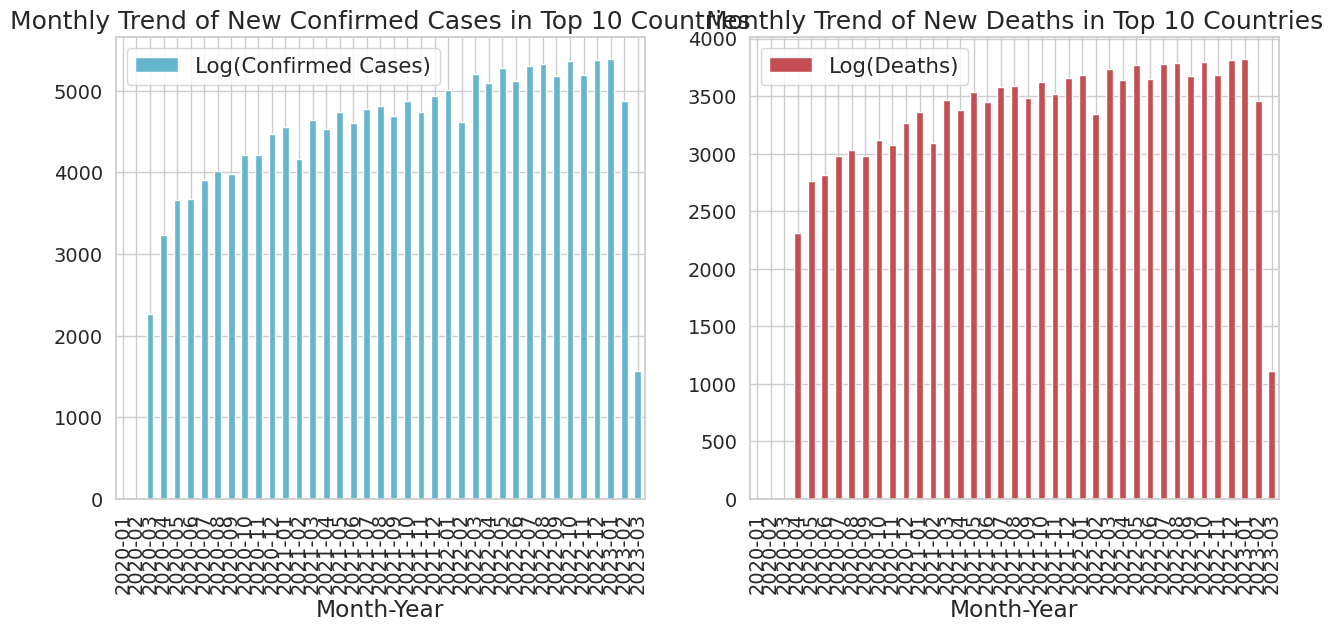

In [ ]:
# BAR CHART: Plot total new cases in top 10 countries
# Set up matplotlib figure
f, ax = plt.subplots(figsize=(15,6), ncols=2, sharex=False)

# Set figure style
sns.set(style="whitegrid")
sns.set_context("notebook", font_scale=1.4, rc={"lines.linewidth":4, "axes.titlesize":18})


# Plot Monthly Trend of New Confirmed Cases in top 10 countries
top10_country_cases.groupby("Month-Year")['Log(Confirmed Cases)'].sum().plot(kind="bar",
    title="Monthly Trend of New Confirmed Cases in Top 10 Countries", color="c", legend="True", fontsize=14, ax=ax[0])

# Plot Monthly Trend of New Deaths in top 10 countries
top10_country_cases.groupby("Month-Year")['Log(Deaths)'].sum().plot(kind="bar",
    title="Monthly Trend of New Deaths in Top 10 Countries", color="r", legend="True", fontsize=14, ax=ax[1])
plt.show()


### Boxplot Analysis: Distribution of New Confirmed Cases and Deaths by Month in Top 10 Countries

<ipython-input-89-57d669ecffd5>:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




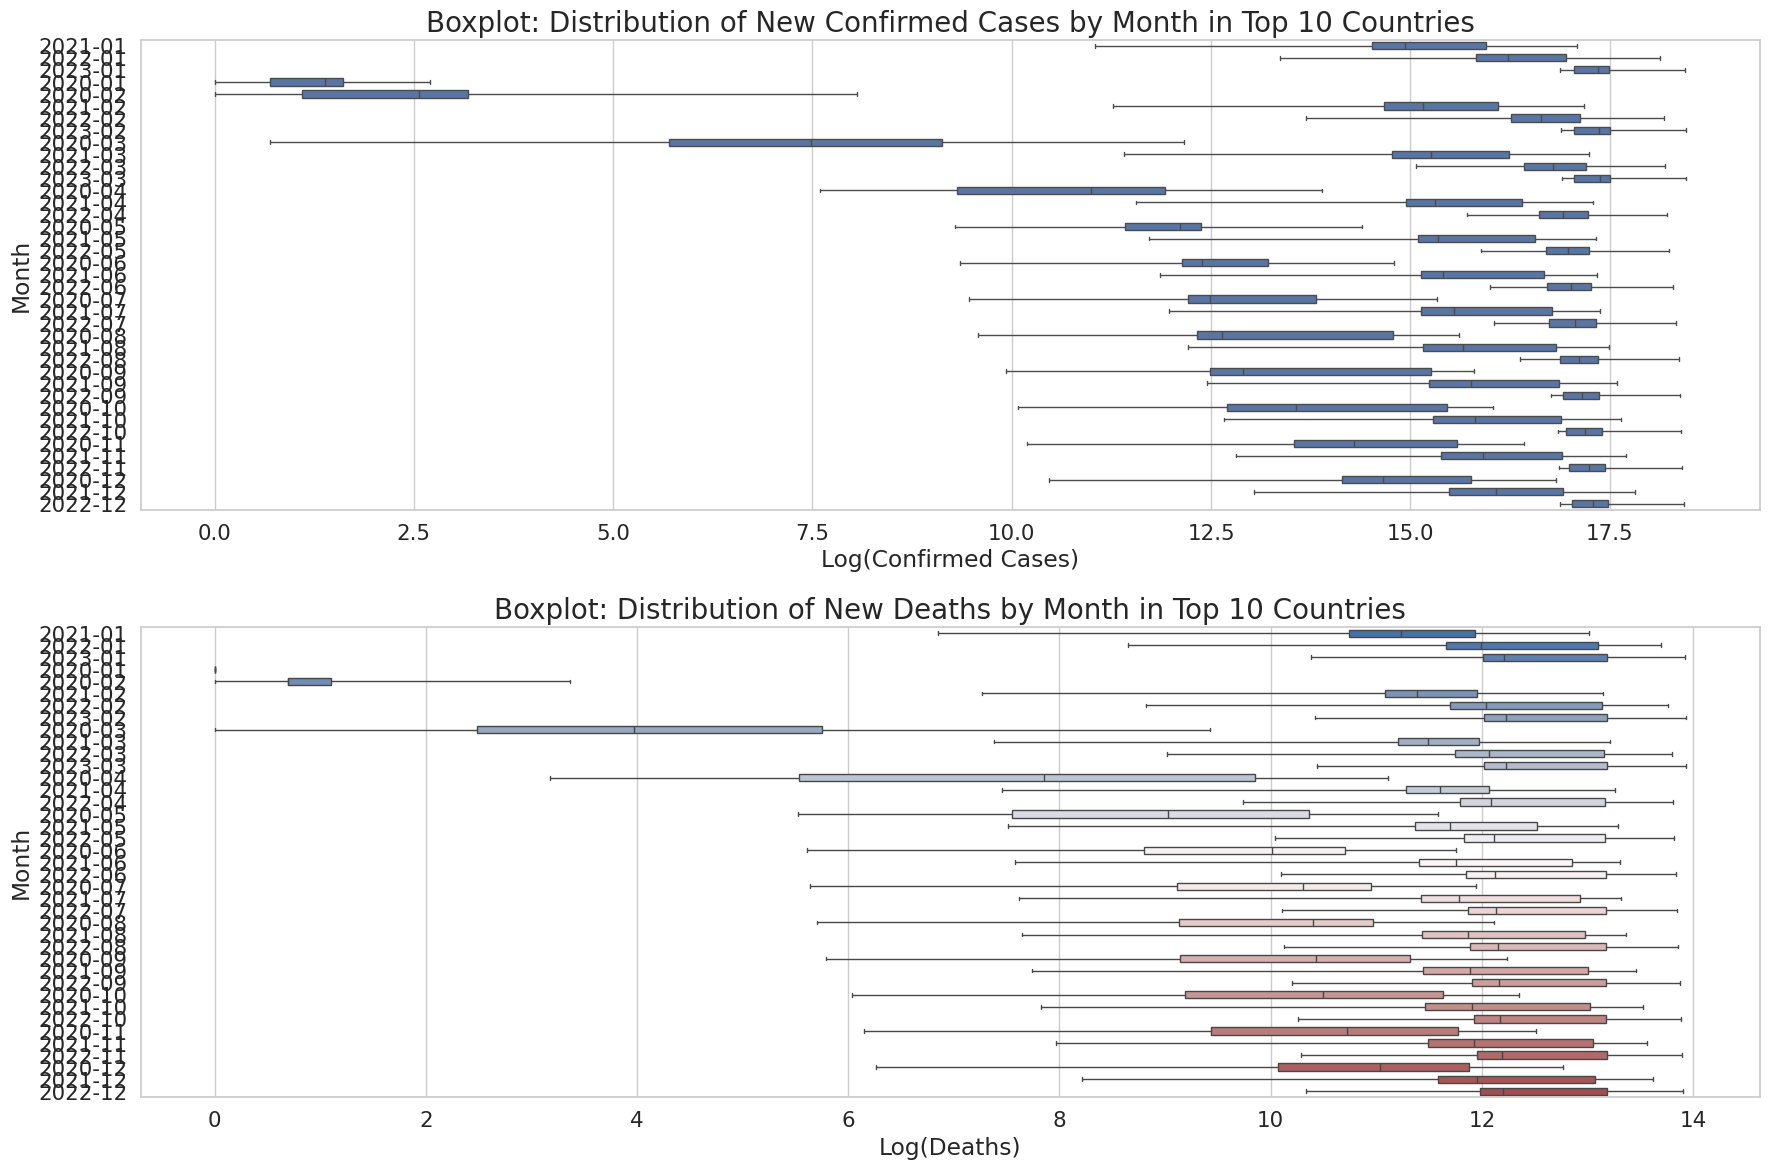

In [ ]:
# Boxplot Analysis: Distribution of New Confirmed Cases and Deaths by Month in Top 10 Countries
sns.set(style="whitegrid")
sns.set_context("notebook", font_scale=1.4, rc={"lines.linewidth":2, "axes.titlesize":20})

# Create subplots layout
f, ax = plt.subplots(figsize=(18, 12), nrows=2)  # Use nrows=2 to create two rows of subplots

# Plot new confirmed cases distribution by month in top 10 countries
sns.boxplot(x="Log(Confirmed Cases)", y="Month-Year", data=top10_country_cases, whis=[0, 100], width=.6, ax=ax[0])

# Add in points to show each obersvation
# sns.stripplot(x="Log(Confirmed Cases)", y="Month-Year", data=top10_country_cases, size=4, color=".1", linewidth=0,ax=ax[0])

# Tweak the visual presentation
ax[0].xaxis.grid(True)
ax[0].set(ylabel="Month", title="Boxplot: Distribution of New Confirmed Cases by Month in Top 10 Countries")

# Plot new deaths distribution by month in top 10 countries
sns.boxplot(x="Log(Deaths)", y="Month-Year", data=top10_country_cases, whis=[0, 100], width=.6, ax=ax[1], palette="vlag")

# Add in points to show each obersvation
# sns.stripplot(x="Log(Deaths)", y="Month-Year", data=top10_country_cases, size=4, color=".1", linewidth=0,ax=ax[1])

# Tweak the visual presentation
ax[1].xaxis.grid(True)
ax[1].set(ylabel="Month", title="Boxplot: Distribution of New Deaths by Month in Top 10 Countries")

# Adjust layout to avoid overlapping
plt.tight_layout()

plt.show();


<ipython-input-90-7e0507a195a1>:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




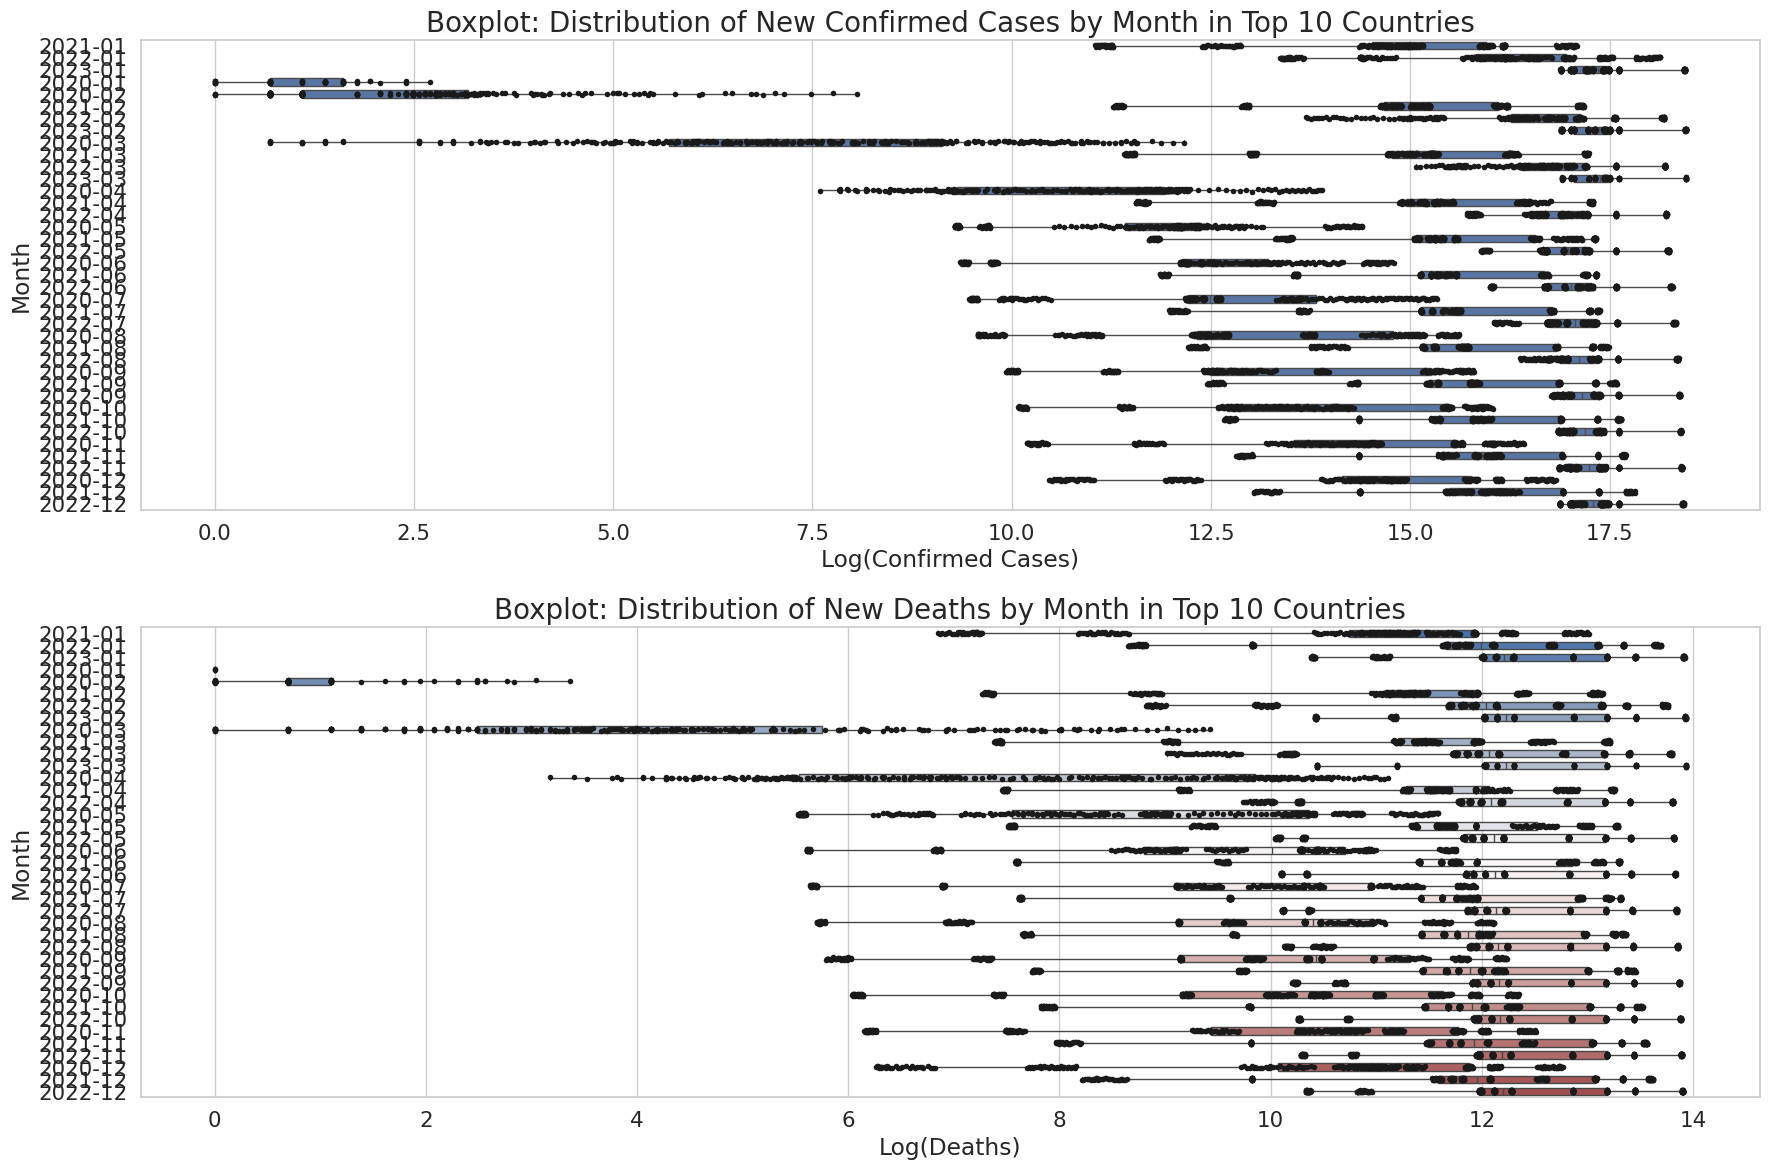

In [ ]:
# Boxplot Analysis: Distribution of New Confirmed Cases and Deaths by Month in Top 10 Countries
sns.set(style="whitegrid")
sns.set_context("notebook", font_scale=1.4, rc={"lines.linewidth":2, "axes.titlesize":20})

# Create subplots layout
f, ax = plt.subplots(figsize=(18, 12), nrows=2)  # Use nrows=2 to create two rows of subplots

# Plot new confirmed cases distribution by month in top 10 countries
sns.boxplot(x="Log(Confirmed Cases)", y="Month-Year", data=top10_country_cases, whis=[0, 100], width=.6, ax=ax[0])

# Add in points to show each obersvation
sns.stripplot(x="Log(Confirmed Cases)", y="Month-Year", data=top10_country_cases, size=4, color=".1", linewidth=0,ax=ax[0])

# Tweak the visual presentation
ax[0].xaxis.grid(True)
ax[0].set(ylabel="Month", title="Boxplot: Distribution of New Confirmed Cases by Month in Top 10 Countries")

# Plot new deaths distribution by month in top 10 countries
sns.boxplot(x="Log(Deaths)", y="Month-Year", data=top10_country_cases, whis=[0, 100], width=.6, ax=ax[1], palette="vlag")

# Add in points to show each obersvation
sns.stripplot(x="Log(Deaths)", y="Month-Year", data=top10_country_cases, size=4, color=".1", linewidth=0,ax=ax[1])

# Tweak the visual presentation
ax[1].xaxis.grid(True)
ax[1].set(ylabel="Month", title="Boxplot: Distribution of New Deaths by Month in Top 10 Countries")

# Adjust layout to avoid overlapping
plt.tight_layout()

plt.show();


In [ ]:
!pip install -U kaleido

### Visualizing COVID-19 New Cases in a Heat Map Calendar for Top 10 Countries

<ipython-input-92-a27a48ea23e6>:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-92-a27a48ea23e6>:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



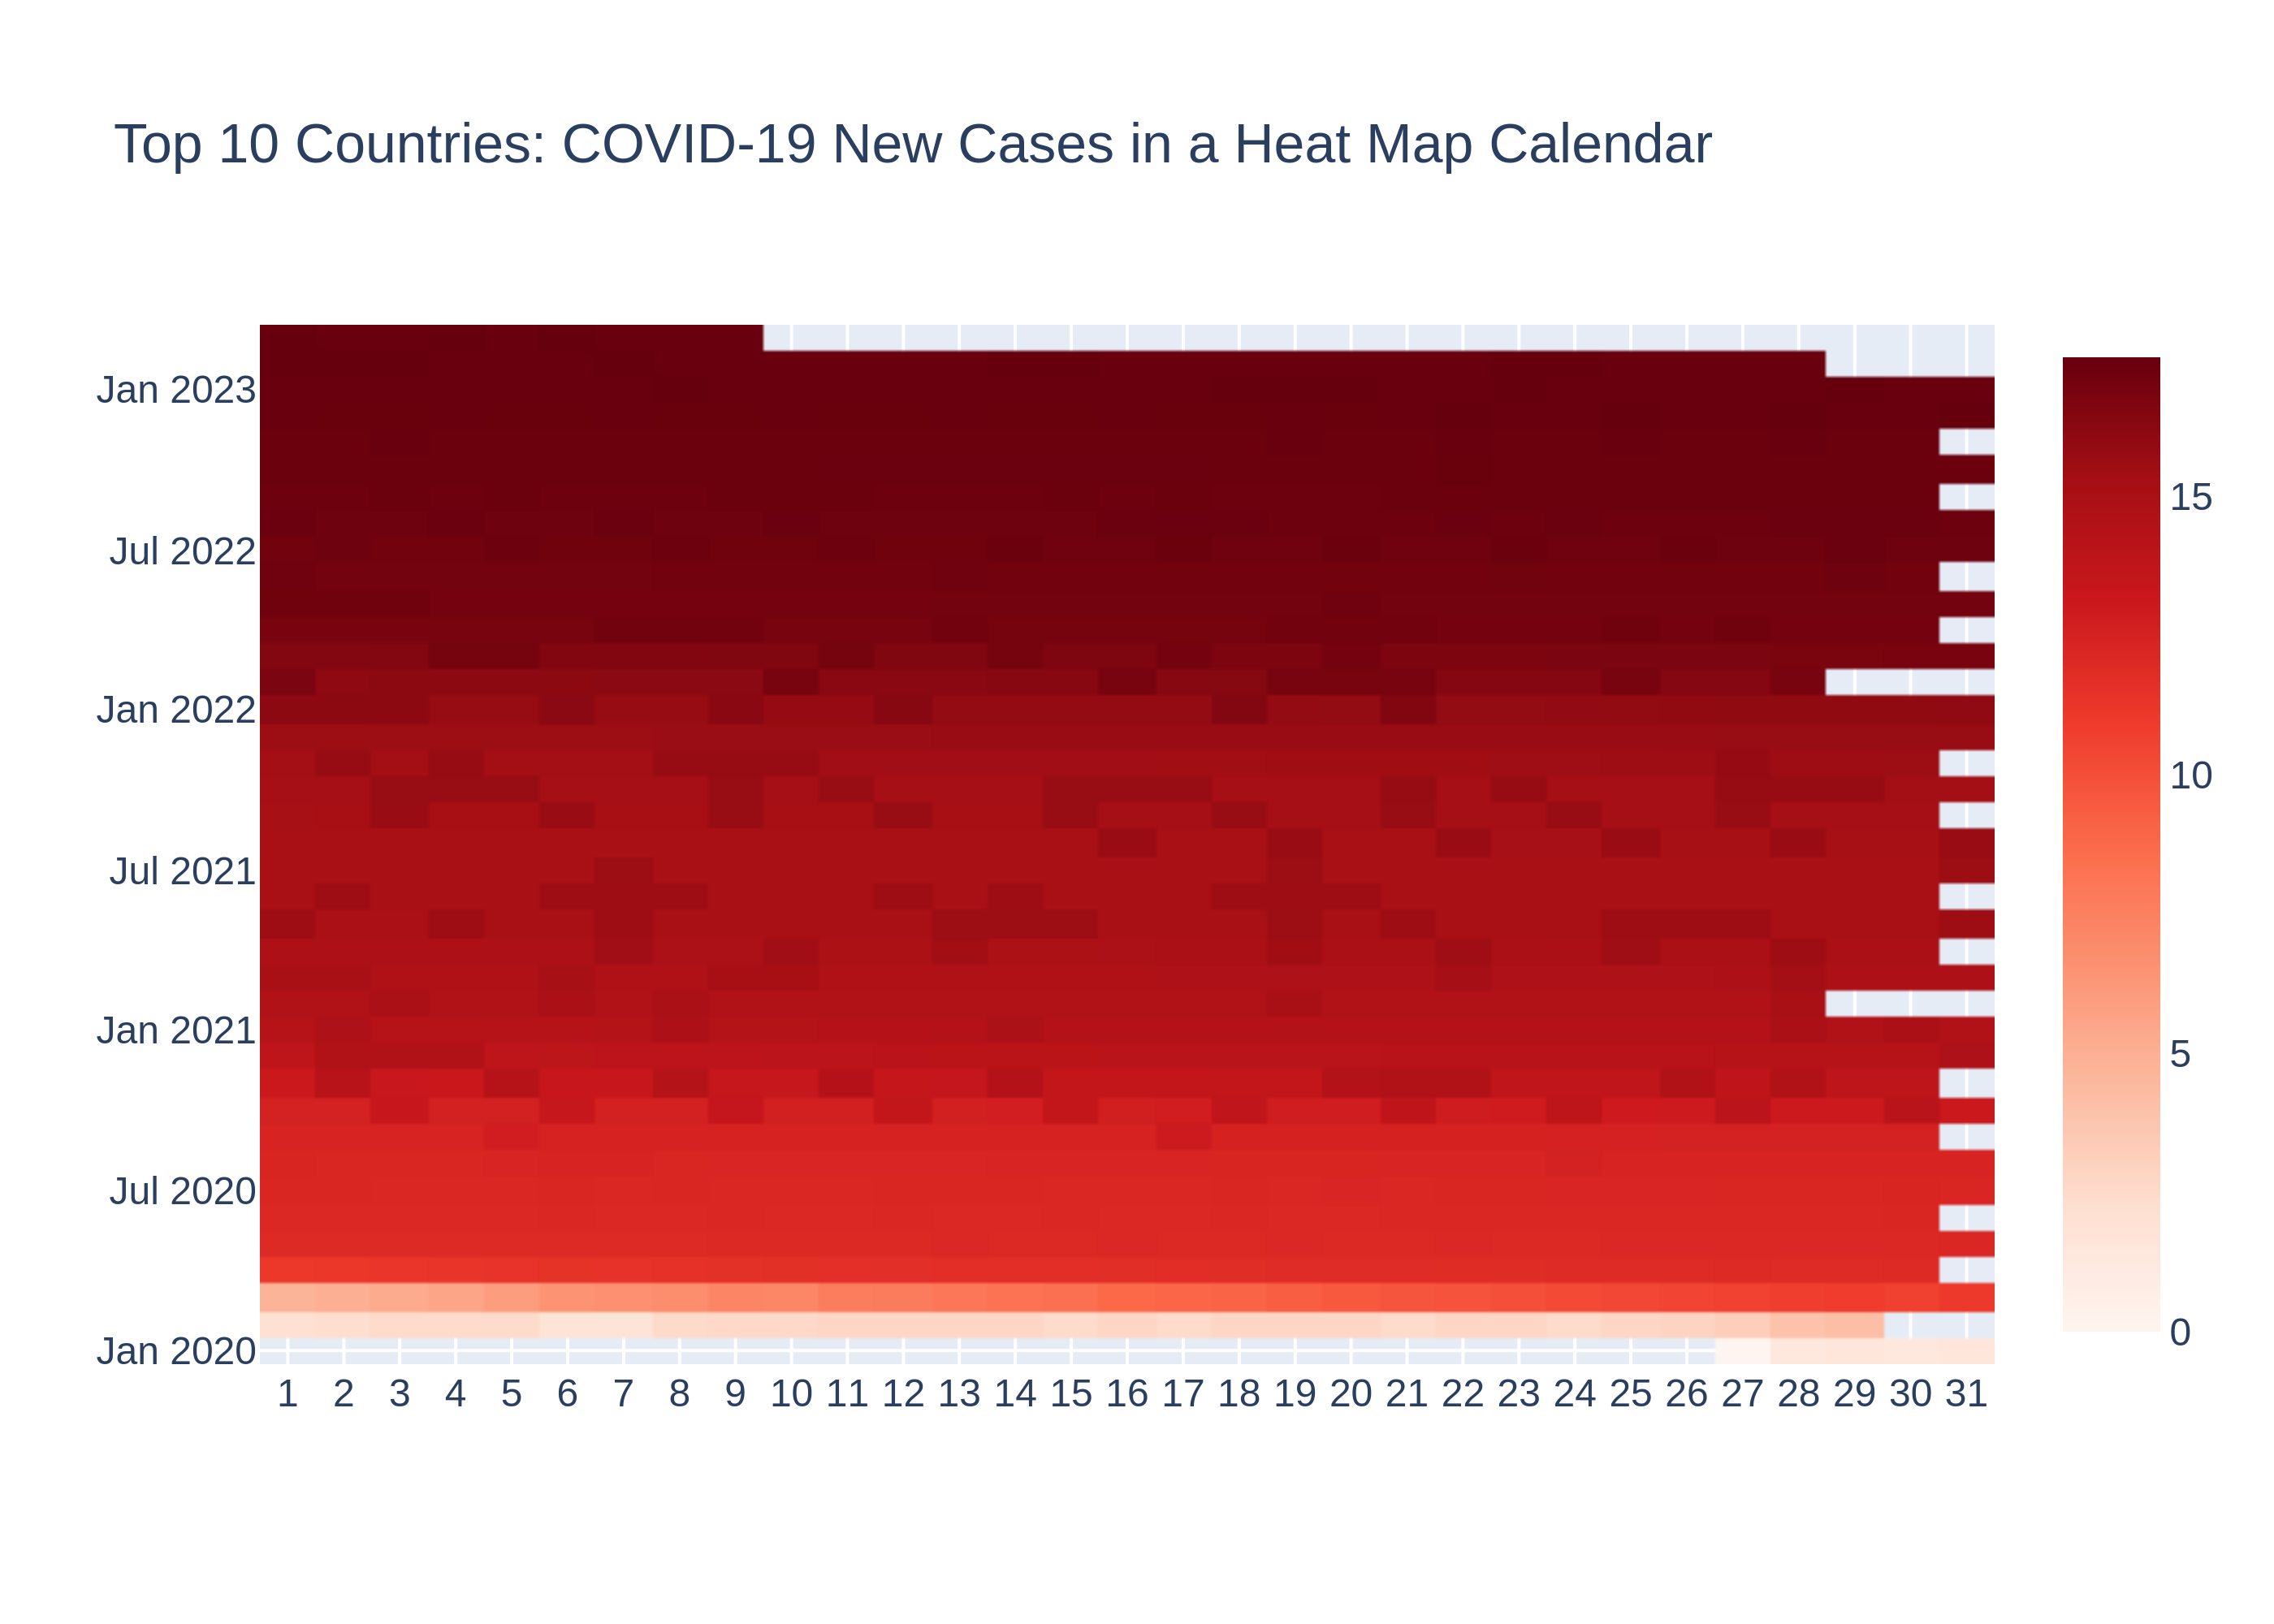

In [ ]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import Image

# Convert Month-Year and Day columns to strings
top10_country_cases['Month-Year'] = top10_country_cases['Month-Year'].apply(str)
top10_country_cases['Day'] = top10_country_cases['Day'].apply(str)

# Create a heatmap demonstrating the number of new cases
fig7 = go.Figure(data=go.Heatmap(
    z=top10_country_cases['Log(Confirmed Cases)'],
    x=top10_country_cases['Day'],
    y=top10_country_cases['Month-Year'],
    colorscale='Reds'  # Change the colorscale to Reds
))

# Update layout of the heatmap
fig7.update_layout(title='Top 10 Countries: COVID-19 New Cases in a Heat Map Calendar')

# Write the heatmap to an image file
pio.write_image(fig7, "Top_10_Countries_New_Cases_Calendar_Heatmap_RedGradient.png", format='png', scale=4)

# Display the heatmap as an image
Image(pio.to_image(fig7, format='png', scale=4))



--- ---



# Statistical Analysis

# Descriptive Statistics

In [ ]:
# 1. Descriptive statistics
print("Descriptive Statistics:")
print(country_data.describe())
print("\n")

Descriptive Statistics:
       Confirmed Cases        Deaths  fatality_rate
count     2.010000e+02  2.010000e+02     201.000000
mean      3.365951e+06  3.423762e+04       4.472976
std       1.012228e+07  1.108256e+05      42.272578
min       1.000000e+00  0.000000e+00       0.000000
25%       3.749100e+04  3.720000e+02       0.516599
50%       3.173670e+05  3.164000e+03       1.075774
75%       1.704502e+06  1.907100e+04       1.918753
max       1.038027e+08  1.123836e+06     600.000000




In [ ]:
# Country_data
india_data = country_data.loc[country_data['Country/Region'] == 'India']
print("Up till {}".format(final_date))
print("India has {} confirmed cases, {} deaths, and {}% fatality rate".\
      format(india_data['Confirmed Cases'].iloc[0],
            india_data['Deaths'].iloc[0],
            india_data['fatality_rate'].iloc[0]))

Up till 03/09/2023
India has 44690738 confirmed cases, 530779 deaths, and 1.1876711456409603% fatality rate


# Hypothesis Test for Fatality Rate Comparison between India and Top-10 Fatality Rate Countries

In [ ]:
# 2. T-test (comparing fatality rates between India and Top-10 Fatality Rate Countries)
usa_data = country_data.loc[country_data['Country/Region'] == 'USA']

t_statistic, p_value = stats.ttest_ind(india_data['fatality_rate'].values, country_data['fatality_rate'].values, nan_policy='omit')
print("T-test for Fatality Rate:")
print("T-statistic:", t_statistic)
print("P-value:", p_value)
if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in fatality rates.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in fatality rates.")
print("\n")

T-test for Fatality Rate:
T-statistic: -0.0775245458721409
P-value: 0.9382837671308051
Fail to reject the null hypothesis: There is no significant difference in fatality rates.




### Correlation between Confirmed Cases and Deaths

In [ ]:
# 3. Correlation between confirmed cases and deaths
correlation = country_data['Confirmed Cases'].corr(country_data['Deaths'])
print("Correlation between Confirmed Cases and Deaths:")
print("Correlation coefficient:", correlation)
print("\n")

Correlation between Confirmed Cases and Deaths:
Correlation coefficient: 0.8766513715829531




### Chi-square test for Independence between Confirmed Cases and Deaths

In [ ]:
# 4. Chi-square test (testing independence between confirmed cases and deaths)
observed = country_data[['Confirmed Cases', 'Deaths']].values
chi2, p, dof, expected = stats.chi2_contingency(observed)
print("Chi-square test for Independence between Confirmed Cases and Deaths:")
print("Chi-square statistic:", chi2)
print("P-value:", p)
if p < 0.05:
    print("Reject the null hypothesis: Confirmed Cases and Deaths are dependent.")
else:
    print("Fail to reject the null hypothesis: Confirmed Cases and Deaths are independent.")

print("Variance of Fatality Rate :", country_data['fatality_rate'].var())

Chi-square test for Independence between Confirmed Cases and Deaths:
Chi-square statistic: 4208407.559601114
P-value: 0.0
Reject the null hypothesis: Confirmed Cases and Deaths are dependent.
Variance of Fatality Rate : 1786.970821550586


In [ ]:
# Read the Population Dataset
population = pd.read_csv('WorldPopulation2023.csv')
population.head()

,Rank,Country,Population2023,YearlyChange,NetChange,Density(P/Km²),Land Area(Km²),Migrants(net),Fert.Rate,MedianAge,UrbanPop%,WorldShare
0,36,Afghanistan,42239854,2.70 %,1111083,65,652860,-65846,4.4,17.0,26 %,0.53 %
1,138,Albania,2832439,-0.35 %,-9882,103,27400,-8000,1.4,38.0,67 %,0.04 %
2,34,Algeria,45606480,1.57 %,703255,19,2381740,-9999,2.8,28.0,75 %,0.57 %
3,212,American Samoa,43914,-0.81 %,-359,220,200,-790,2.2,29.0,N.A.,0.00 %
4,202,Andorra,80088,0.33 %,264,170,470,200,1.1,43.0,85 %,0.00 %


Linear Regression Analysis

### Linear Regression Analysis: Assessing the Dependency of Fatality Rate on Population

In [ ]:
import pandas as pd
import statsmodels.api as sm

population['Intercept'] = 1

# Merge country_data with population dataset based on country/region column
merged_data = pd.merge(country_data, population, left_on='Country/Region', right_on='Country', how='inner')

# Prepare the independent variables matri
X = merged_data[['Population2023', 'Intercept']]

# Define the dependent variable
y = merged_data['fatality_rate']

# Fit the linear regression model
model = sm.OLS(y, X).fit()

# Print the summary of the regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          fatality_rate   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.5757
Date:                Mon, 29 Apr 2024   Prob (F-statistic):              0.449
Time:                        10:56:21   Log-Likelihood:                -357.21
No. Observations:                 184   AIC:                             718.4
Df Residuals:                     182   BIC:                             724.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Population2023  6.246e-10   8.23e-10      0.

# Significance of Coefficients in Linear Regression Analysis

In [ ]:
# Print the significance of coefficients
print("\nSignificance of Coefficients:")
print("Population2023 p-value:", model.pvalues['Population2023'])
print("Intercept p-value:", model.pvalues['Intercept'])

# Interpretation of p-values
if model.pvalues['Population2023'] > 0.05:
    print("The coefficient for Population2023 is not statistically significant.")
else:
    print("The coefficient for Population2023 is statistically significant.")

if model.pvalues['Intercept'] > 0.05:
    print("The Intercept is not statistically significant.")
else:
    print("The Intercept is statistically significant.")


Significance of Coefficients:
Population2023 p-value: 0.44898829847694266
Intercept p-value: 2.6486653719584404e-21
The coefficient for Population2023 is not statistically significant.
The Intercept is statistically significant.
